In [17]:
import json
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import read, read_inventory, UTCDateTime
from obspy.geodetics import gps2dist_azimuth
from obspy.signal.util import next_pow_2

warnings.filterwarnings("ignore")

In [18]:
VOLCANO = {
    "name": "pavlof_2021",
    "lat": 55.4173,
    "lon": -161.8937,
}

PATHS = {
    "data_base": Path("/home/elizabeth/soft/src/QuickQuake/data"),
    "catalog_csv": Path("/home/elizabeth/soft/src/QuickQuake/data/merged/output/GAMMA_hypodd_catalog_qcfiltered.csv"),
    "picks_csv": Path("/home/elizabeth/soft/src/QuickQuake/data/merged/gammapicks_id.csv"),
    "stations_json": Path("/home/elizabeth/soft/src/QuickQuake/data/merged/input/GAMMA_station_list.json"),
    "inventory_xml": Path("/home/elizabeth/soft/src/QuickQuake/data/merged/input/stations_merged.xml"),
    "output_csv": Path("/home/elizabeth/soft/src/QuickQuake/data/merged/output/catalog_with_fi_results.csv"),
    "output_dir": Path("/home/elizabeth/soft/src/QuickQuake/data/merged/output/fi_outputs"),
}

FILTERS = {
    "event_radius_km": 100.0,
    "station_max_dist_km": 67.0,
    "min_stations": 2,
    "snr_threshold": 2.0,
}

WINDOWS = {
    "p_rel_start_s": -1.0,
    "p_win_len_s": 7.0,
    "pre_pick_s": 5.0,
    "post_pick_s": 25.0,
    "noise_win_s": 5.0,
}

METHODS = {
    "song_tan_2025": {
        "enabled": True,
        "label": "Song & Tan (2025)",
        "f_low": (1.0, 5.0),
        "f_high": (8.0, 14.0),
        "remove_response": True,
        "classification_mode": "binary",
        "default_threshold": -0.75,
    },
    "buurman_west_style": {
        "enabled": True,
        "label": "Buurman & West style",
        "f_low": (1.0, 2.0),
        "f_high": (10.0, 20.0),
        "remove_response": False,
        "classification_mode": "three_class",
        "thresholds": {
            "lf_upper": -1.3,
            "hf_lower": -0.4,
        },
    },
}

PATHS["output_dir"].mkdir(parents=True, exist_ok=True)

In [19]:
from datetime import timedelta

def build_chunk_index(data_base):
    chunk_rows = []

    for p in sorted(Path(data_base).iterdir()):
        if not p.is_dir():
            continue
        if p.name == "merged":
            continue

        try:
            start = pd.to_datetime(p.name, format="%Y%m%dT%H%M%S", utc=True)
            chunk_rows.append({"folder": p.name, "start": start})
        except Exception:
            continue

    chunk_df = pd.DataFrame(chunk_rows).sort_values("start").reset_index(drop=True)

    if len(chunk_df) == 0:
        raise ValueError(f"No valid chunk folders found in {data_base}")

    # infer end times from next chunk start
    chunk_df["end"] = chunk_df["start"].shift(-1)

    # for the last chunk, assume same duration as previous if possible, else 8 hours
    if len(chunk_df) > 1:
        last_duration = chunk_df.loc[len(chunk_df)-2, "end"] - chunk_df.loc[len(chunk_df)-2, "start"]
    else:
        last_duration = pd.Timedelta(hours=8)

    chunk_df.loc[len(chunk_df)-1, "end"] = chunk_df.loc[len(chunk_df)-1, "start"] + last_duration

    return chunk_df


def find_chunk_folder_for_event(event_time, chunk_index):
    match = chunk_index[(chunk_index["start"] <= event_time) & (event_time < chunk_index["end"])]
    if len(match) == 0:
        return None
    return match.iloc[0]["folder"]

In [20]:
chunk_index = build_chunk_index(PATHS["data_base"])
print(chunk_index.head())
print(f"Chunk folders found: {len(chunk_index)}")

            folder                     start                       end
0  20210729T080000 2021-07-29 08:00:00+00:00 2021-07-29 16:00:00+00:00
1  20210729T160000 2021-07-29 16:00:00+00:00 2021-07-30 00:00:00+00:00
Chunk folders found: 2


In [21]:
def horizontal_distance_km(lat1, lon1, lat2, lon2):
    dist_m, _, _ = gps2dist_azimuth(lat1, lon1, lat2, lon2)
    return dist_m / 1000.0


def get_hypocentral_distances(stations_df, ev_lat, ev_lon, ev_depth_km):
    stations_df = stations_df.copy()

    if "elev_km" not in stations_df.columns:
        stations_df["elev_km"] = 0.0

    hypo_distances = []
    for _, sta in stations_df.iterrows():
        dh_km = horizontal_distance_km(ev_lat, ev_lon, float(sta["lat"]), float(sta["lon"]))
        dz_km = ev_depth_km + float(sta["elev_km"])
        d3_km = np.sqrt(dh_km**2 + dz_km**2)
        hypo_distances.append(d3_km)

    stations_df["hypo_km"] = hypo_distances
    distance_map = dict(zip(stations_df["sta_id"], stations_df["hypo_km"]))

    return distance_map, stations_df


def filter_catalog_by_radius(df, volcano, radius_km, lat_col="latitude", lon_col="longitude"):
    out = df.copy()
    out["r_km"] = [
        horizontal_distance_km(lat, lon, volcano["lat"], volcano["lon"])
        for lat, lon in zip(out[lat_col], out[lon_col])
    ]
    out["inside_radius"] = out["r_km"] <= radius_km
    out_filtered = out[out["inside_radius"]].copy().reset_index(drop=True)
    return out, out_filtered

In [22]:
def infer_catalog_columns(df):
    colmap = {}

    candidates = {
        "time": ["datetime", "time", "origin_time"],
        "latitude": ["latitude", "lat"],
        "longitude": ["longitude", "lon"],
        "depth_km": ["depth_km", "depth"],
        "event_id": ["event_id", "id"],
        "magnitude": ["mag", "magnitude"],
    }

    for key, options in candidates.items():
        found = None
        for col in options:
            if col in df.columns:
                found = col
                break
        colmap[key] = found

    missing_required = [k for k in ["time", "latitude", "longitude"] if colmap[k] is None]
    if missing_required:
        raise ValueError(
            f"Catalog is missing required columns: {missing_required}. "
            f"Available columns: {list(df.columns)}"
        )

    return colmap


def load_catalog(catalog_csv):
    catalog = pd.read_csv(catalog_csv)
    colmap = infer_catalog_columns(catalog)

    catalog[colmap["time"]] = pd.to_datetime(
        catalog[colmap["time"]], utc=True, errors="coerce"
    )
    catalog = catalog.dropna(subset=[colmap["time"]]).reset_index(drop=True)

    return catalog, colmap


def load_picks(picks_csv):
    picks = pd.read_csv(picks_csv)

    if "timestamp" not in picks.columns:
        raise ValueError("The picks file must contain a 'timestamp' column.")

    picks["timestamp"] = pd.to_datetime(picks["timestamp"], utc=True, errors="coerce")
    picks = picks.dropna(subset=["timestamp"]).reset_index(drop=True)

    if "id" in picks.columns:
        id_parts = picks["id"].astype(str).str.split(".", expand=True)
        if id_parts.shape[1] >= 2:
            picks["net"] = id_parts[0]
            picks["sta"] = id_parts[1]

    if "net" in picks.columns and "sta" in picks.columns:
        picks["sta_id"] = picks["net"].astype(str) + "." + picks["sta"].astype(str)
    else:
        raise ValueError("Could not build 'sta_id'. Need either 'id' or both 'net' and 'sta' columns.")

    return picks


def load_stations(stations_json):
    with open(stations_json, "r") as f:
        stations_raw = json.load(f)

    stations_list = []

    for code, values in stations_raw.items():
        parts = code.split(".")
        net = parts[0] if len(parts) > 0 else ""
        sta = parts[1] if len(parts) > 1 else ""
        sta_id = f"{net}.{sta}" if net and sta else code

        elev_m = None
        if "elevation(m)" in values:
            elev_m = values["elevation(m)"]
        elif "elev_m" in values:
            elev_m = values["elev_m"]
        elif "elevation_m" in values:
            elev_m = values["elevation_m"]

        elev_km = float(elev_m) / 1000.0 if elev_m is not None else 0.0

        stations_list.append({
            "sta_id": sta_id,
            "net": net,
            "sta": sta,
            "lat": values.get("latitude"),
            "lon": values.get("longitude"),
            "elev_km": elev_km,
        })

    stations = pd.DataFrame(stations_list)

    required_cols = ["sta_id", "lat", "lon", "elev_km"]
    for col in required_cols:
        if col not in stations.columns:
            raise ValueError(f"Missing required station column: {col}")

    return stations


def load_inventory(inventory_xml):
    if inventory_xml is None:
        return None

    inventory_xml = Path(inventory_xml)

    if not inventory_xml.exists():
        print(f"Inventory file not found: {inventory_xml}")
        return None

    try:
        inventory = read_inventory(str(inventory_xml))
        return inventory
    except Exception as e:
        print(f"Error loading inventory XML: {e}")
        return None

In [23]:
catalog, catalog_colmap = load_catalog(PATHS["catalog_csv"])
picks = load_picks(PATHS["picks_csv"])
stations = load_stations(PATHS["stations_json"])
inventory = load_inventory(PATHS["inventory_xml"])

print("Catalog columns:", catalog.columns.tolist())
print("Catalog mapping:", catalog_colmap)
print(f"Catalog events: {len(catalog)}")
print(f"Picks: {len(picks)}")
print(f"Stations: {len(stations)}")
print(f"Inventory loaded: {inventory is not None}")

catalog_full, catalog_filtered = filter_catalog_by_radius(
    catalog,
    VOLCANO,
    FILTERS["event_radius_km"],
    lat_col=catalog_colmap["latitude"],
    lon_col=catalog_colmap["longitude"],
)

print(f"Events inside {FILTERS['event_radius_km']} km: {len(catalog_filtered)} / {len(catalog)}")
catalog_filtered.head()

Catalog columns: ['time', 'latitude', 'longitude', 'depth_km', 'magnitude', 'event_id', 'pc_ratio_energy']
Catalog mapping: {'time': 'time', 'latitude': 'latitude', 'longitude': 'longitude', 'depth_km': 'depth_km', 'event_id': 'event_id', 'magnitude': 'magnitude'}
Catalog events: 48
Picks: 1832
Stations: 11
Inventory loaded: True
Events inside 100.0 km: 48 / 48


,time,latitude,longitude,depth_km,magnitude,event_id,pc_ratio_energy,r_km,inside_radius
0,2021-07-29 23:38:44.800000+00:00,55.277486,-160.796175,45.20,2.26,102,5.39,71.344863,True
1,2021-07-29 09:08:20.310000+00:00,55.136080,-161.006738,40.73,2.02,11,2.60,64.479194,True
2,2021-07-29 09:17:37.990000+00:00,55.306222,-160.979150,47.08,2.17,12,5.93,59.301330,True
3,2021-07-29 09:23:23.330000+00:00,55.277091,-160.916276,45.55,2.00,13,4.46,63.942049,True
4,2021-07-29 09:43:53.380000+00:00,55.085364,-161.641488,17.55,1.37,18,8.23,40.284367,True


In [24]:
def calculate_snr(signal_data, noise_data):
    if len(signal_data) == 0 or len(noise_data) == 0:
        return 0.0

    signal_rms = np.sqrt(np.mean(signal_data**2))
    noise_rms = np.sqrt(np.mean(noise_data**2))

    if noise_rms == 0:
        return np.inf

    return signal_rms / noise_rms


def extract_signal_and_noise_windows(trace, p_arrival_time, windows):
    signal_start = p_arrival_time + windows["p_rel_start_s"]
    signal_end = signal_start + windows["p_win_len_s"]
    noise_start = signal_start - windows["noise_win_s"]
    noise_end = signal_start

    signal_trace = trace.copy()
    signal_trace.trim(signal_start, signal_end, pad=True, fill_value=0.0)

    noise_trace = trace.copy()
    noise_trace.trim(noise_start, noise_end, pad=True, fill_value=0.0)

    return signal_trace, noise_trace


def preprocess_trace(trace):
    tr = trace.copy()
    tr.data = tr.data.astype(float)
    tr.detrend("demean")
    tr.detrend("linear")
    tr.taper(max_percentage=0.05, type="hann")
    return tr


def compute_amplitude_spectrum(trace):
    data = trace.data.astype(float)
    npts = len(data)

    if npts < 10:
        return None, None

    if not np.all(np.isfinite(data)):
        return None, None

    window = np.hanning(npts)
    data_windowed = data * window

    # ObsPy next_pow_2 ya devuelve el tamaño correcto
    nfft = next_pow_2(npts)

    spectrum = np.fft.rfft(data_windowed, n=nfft)
    freqs = np.fft.rfftfreq(nfft, d=trace.stats.delta)
    amp = np.abs(spectrum)

    return freqs, amp

In [25]:
def remove_instrument_response(trace, inventory):
    corrected_trace = trace.copy()

    try:
        fs = corrected_trace.stats.sampling_rate
        nyq = 0.5 * fs

        f1 = 0.5
        f2 = 1.0
        f3 = min(0.9 * nyq, nyq - 1.0)
        f4 = min(0.95 * nyq, nyq - 0.1)

        if not (f1 < f2 < f3 < f4):
            return corrected_trace, False

        corrected_trace.remove_response(
            inventory=inventory,
            output="VEL",
            water_level=60,
            pre_filt=(f1, f2, f3, f4),
        )
        return corrected_trace, True

    except Exception:
        try:
            corrected_trace = trace.copy()
            corrected_trace.remove_response(
                inventory=inventory,
                output="VEL",
                water_level=60,
            )
            return corrected_trace, True
        except Exception:
            return trace, False


def compute_station_fi(
    trace,
    p_arrival_time,
    method_config,
    windows,
    snr_threshold,
    inventory=None,
):
    try:
        signal_trace, noise_trace = extract_signal_and_noise_windows(trace, p_arrival_time, windows)

        snr = calculate_snr(signal_trace.data.astype(float), noise_trace.data.astype(float))
        if snr < snr_threshold:
            return None

        processed = preprocess_trace(signal_trace)

        if method_config["remove_response"]:
            if inventory is None:
                return None
            processed, success = remove_instrument_response(processed, inventory)
            if not success:
                return None

        if np.any(~np.isfinite(processed.data)):
            return None

        freqs, amp = compute_amplitude_spectrum(processed)
        if freqs is None or amp is None:
            return None

        f_low_min, f_low_max = method_config["f_low"]
        f_high_min, f_high_max = method_config["f_high"]

        low_mask = (freqs >= f_low_min) & (freqs <= f_low_max)
        high_mask = (freqs >= f_high_min) & (freqs <= f_high_max)

        if not np.any(low_mask) or not np.any(high_mask):
            return None

        a_low = np.mean(amp[low_mask])
        a_high = np.mean(amp[high_mask])

        if not np.isfinite(a_low) or not np.isfinite(a_high):
            return None
        if a_low <= 0:
            return None

        fi = np.log10(a_high / a_low)

        return {
            "fi": float(fi),
            "snr": float(snr),
            "a_low": float(a_low),
            "a_high": float(a_high),
            "npts": int(len(processed.data)),
        }

    except Exception as e:
        return None

In [26]:
def classify_binary(fi, threshold):
    if not np.isfinite(fi):
        return "NC"
    return "LP" if fi < threshold else "VT"


def classify_three_class(fi, lf_upper=-1.3, hf_lower=-0.4):
    if not np.isfinite(fi):
        return "NC"
    if fi < lf_upper:
        return "LF"
    elif fi > hf_lower:
        return "HF"
    else:
        return "HYBRID"

In [27]:
def process_event(
    event_row,
    picks,
    stations,
    data_base,
    method_name,
    method_config,
    filters,
    windows,
    inventory,
    catalog_colmap,
    chunk_index,
):
    # La columna time ya viene tz-aware desde load_catalog()
    event_time = pd.Timestamp(event_row[catalog_colmap["time"]])
    event_time_obspy = UTCDateTime(event_time.to_pydatetime())

    event_lat = float(event_row[catalog_colmap["latitude"]])
    event_lon = float(event_row[catalog_colmap["longitude"]])

    depth_col = catalog_colmap["depth_km"]
    event_depth = float(event_row[depth_col]) if depth_col is not None else 0.0

    event_id_col = catalog_colmap["event_id"]
    event_id = event_row[event_id_col] if event_id_col is not None else None

    result = {
        "event_id": event_id,
        "event_time": event_time,
        "event_lat": event_lat,
        "event_lon": event_lon,
        "event_depth_km": event_depth,
        "r_km": event_row.get("r_km", np.nan),
        "method": method_name,
        "method_label": method_config["label"],
        "fi": np.nan,
        "fi_std": np.nan,
        "fi_n_stations": 0,
        "fi_snr_mean": np.nan,
        "status": "init",
        "fi_class": "NC",
        "waveform_folder": None,
    }

    distance_map, _ = get_hypocentral_distances(stations, event_lat, event_lon, event_depth)

    # Buscar carpeta de waveforms
    if "original_folder" in event_row.index and pd.notna(event_row["original_folder"]):
        waveform_folder_name = str(event_row["original_folder"])
    else:
        waveform_folder_name = find_chunk_folder_for_event(event_time, chunk_index)

    if waveform_folder_name is None:
        result["status"] = "missing_waveform_folder"
        return result

    result["waveform_folder"] = waveform_folder_name

    folder = Path(data_base) / waveform_folder_name / "waveforms"
    pattern = str(folder / "*.mseed")

    try:
        stream = read(pattern)
        if len(stream) == 0:
            result["status"] = "no_waveforms"
            return result
    except Exception:
        result["status"] = "waveform_read_error"
        return result

    time_min = event_time - pd.Timedelta(seconds=windows["pre_pick_s"])
    time_max = event_time + pd.Timedelta(seconds=windows["post_pick_s"])

    event_picks = picks[
        (picks["timestamp"] >= time_min) &
        (picks["timestamp"] <= time_max)
    ].copy()

    if "type" in event_picks.columns:
        event_picks = event_picks[event_picks["type"].astype(str).str.upper() == "P"].copy()

    if event_picks.empty:
        result["status"] = "no_p_picks"
        return result

    event_picks["hypo_km"] = event_picks["sta_id"].map(distance_map)
    event_picks = event_picks[event_picks["hypo_km"].notna()].copy()
    event_picks = event_picks[event_picks["hypo_km"] <= filters["station_max_dist_km"]].copy()

    if event_picks.empty:
        result["status"] = "no_picks_within_station_distance"
        return result

    if "prob" in event_picks.columns:
        event_picks = (
            event_picks.sort_values("prob", ascending=False)
            .groupby("sta_id", as_index=False)
            .first()
        )
    else:
        event_picks = event_picks.groupby("sta_id", as_index=False).first()

    station_fi = []
    station_snr = []

    for _, pick in event_picks.iterrows():
        sta = str(pick["sta"])
        p_arrival = UTCDateTime(pick["timestamp"].to_pydatetime())

        traces = stream.select(station=sta, channel="*Z")
        if len(traces) == 0:
            continue

        trace = traces[0].copy()

        fi_info = compute_station_fi(
            trace=trace,
            p_arrival_time=p_arrival,
            method_config=method_config,
            windows=windows,
            snr_threshold=filters["snr_threshold"],
            inventory=inventory,
        )

        if fi_info is None:
            continue

        station_fi.append(fi_info["fi"])
        station_snr.append(fi_info["snr"])

    if len(station_fi) < filters["min_stations"]:
        result["status"] = "not_enough_valid_stations"
        return result

    result["fi"] = float(np.mean(station_fi))
    result["fi_std"] = float(np.std(station_fi)) if len(station_fi) > 1 else 0.0
    result["fi_n_stations"] = int(len(station_fi))
    result["fi_snr_mean"] = float(np.mean(station_snr)) if station_snr else np.nan
    result["status"] = "ok"

    if method_config["classification_mode"] == "binary":
        thr = method_config["default_threshold"]
        result["fi_class"] = classify_binary(result["fi"], thr)
        result["threshold_used"] = thr

    elif method_config["classification_mode"] == "three_class":
        lf_upper = method_config["thresholds"]["lf_upper"]
        hf_lower = method_config["thresholds"]["hf_lower"]
        result["fi_class"] = classify_three_class(
            result["fi"],
            lf_upper=lf_upper,
            hf_lower=hf_lower,
        )
        result["threshold_used"] = np.nan
        result["lf_upper"] = lf_upper
        result["hf_lower"] = hf_lower

    return result

In [28]:
results = []

for event_idx, event_row in catalog_filtered.iterrows():
    for method_name, method_cfg in METHODS.items():
        if not method_cfg["enabled"]:
            continue

        event_result = process_event(
            event_row=event_row,
            picks=picks,
            stations=stations,
            data_base=PATHS["data_base"],
            method_name=method_name,
            method_config=method_cfg,
            filters=FILTERS,
            windows=WINDOWS,
            inventory=inventory,
            catalog_colmap=catalog_colmap,
            chunk_index=chunk_index,
        )

        results.append(event_result)

results_df = pd.DataFrame(results)

print(results_df.head())
print("\nStatus counts:")
print(results_df["status"].value_counts(dropna=False))
print("\nClass counts by method:")
print(results_df.groupby(["method", "fi_class"]).size())

   event_id                       event_time  event_lat   event_lon  \
0       102 2021-07-29 23:38:44.800000+00:00  55.277486 -160.796175   
1       102 2021-07-29 23:38:44.800000+00:00  55.277486 -160.796175   
2        11 2021-07-29 09:08:20.310000+00:00  55.136080 -161.006738   
3        11 2021-07-29 09:08:20.310000+00:00  55.136080 -161.006738   
4        12 2021-07-29 09:17:37.990000+00:00  55.306222 -160.979150   

   event_depth_km       r_km              method          method_label  fi  \
0           45.20  71.344863       song_tan_2025     Song & Tan (2025) NaN   
1           45.20  71.344863  buurman_west_style  Buurman & West style NaN   
2           40.73  64.479194       song_tan_2025     Song & Tan (2025) NaN   
3           40.73  64.479194  buurman_west_style  Buurman & West style NaN   
4           47.08  59.301330       song_tan_2025     Song & Tan (2025) NaN   

   fi_std  fi_n_stations  fi_snr_mean                            status  \
0     NaN              0     

Valid FI rows: 46


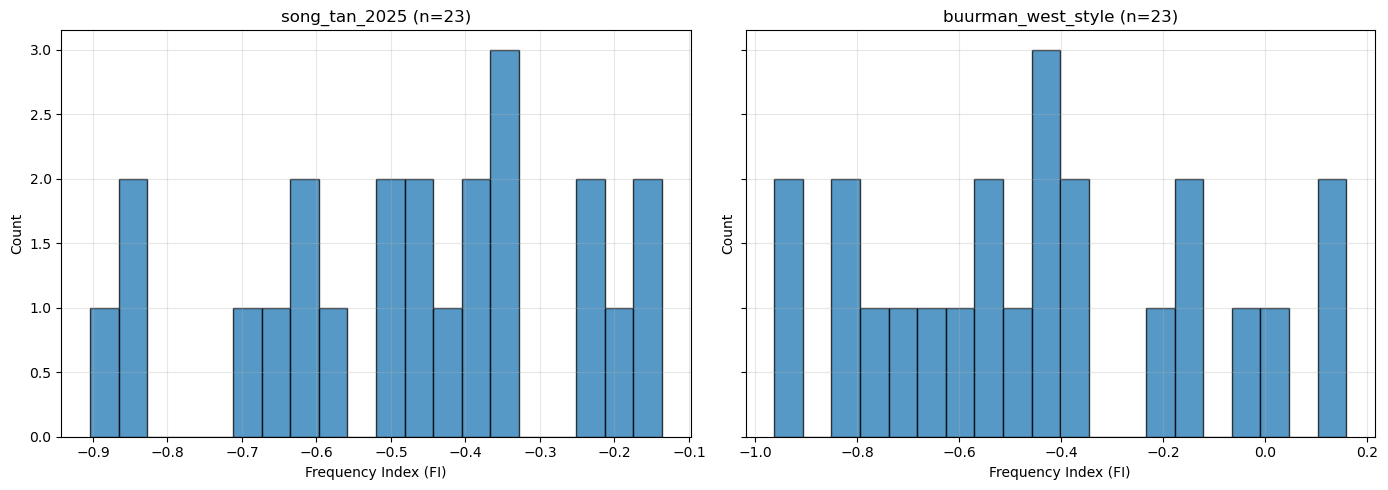

In [29]:
valid_df = results_df[(results_df["status"] == "ok") & (results_df["fi"].notna())].copy()

print(f"Valid FI rows: {len(valid_df)}")

if len(valid_df) == 0:
    print("No hay resultados válidos todavía. Revisa results_df['status'].value_counts().")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    method_list = [m for m in METHODS.keys() if METHODS[m]["enabled"]]

    for ax, method_name in zip(axes, method_list):
        sub = valid_df[valid_df["method"] == method_name].copy()

        if len(sub) == 0:
            ax.set_title(f"{method_name} (sin resultados válidos)")
            ax.grid(alpha=0.3)
            continue

        ax.hist(sub["fi"], bins=20, edgecolor="black", alpha=0.75)
        ax.set_title(f"{method_name} (n={len(sub)})")
        ax.set_xlabel("Frequency Index (FI)")
        ax.set_ylabel("Count")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
results_df.to_csv(PATHS["output_csv"], index=False)
print(f"Saved results to: {PATHS['output_csv']}")